<a href="https://colab.research.google.com/github/Maryam1597/Applieddatascience1/blob/main/Topic_44_jan_26_Model_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Predicting Autism Spectrum Disorder (ASD) Traits in Adults Using Behavioral and Demographic Indicators**

# **Library Installation And Import**

## **Install Required Libraries**

In [ ]:

!pip install ucimlrepo


## **Import Libraries**

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer


# **DATASET LOADING**

In [ ]:
# Fetch dataset
autism_screening_adult = fetch_ucirepo(id=426)

# Features and target
X = autism_screening_adult.data.features
y = autism_screening_adult.data.targets

# Combine for EDA
df = pd.concat([X, y], axis=1)

# Quick checks
print(df.shape)
df.head()


(704, 21)


,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,...,gender,ethnicity,jaundice,family_pdd,country_of_res,used_app_before,result,age_desc,relation,class
0,1,1,1,1,0,0,1,1,0,0,...,f,White-European,no,no,'United States',no,6,'18 and more',Self,NO
1,1,1,0,1,0,0,0,1,0,1,...,m,Latino,no,yes,Brazil,no,5,'18 and more',Self,NO
2,1,1,0,1,1,0,1,1,1,1,...,m,Latino,yes,yes,Spain,no,8,'18 and more',Parent,YES
3,1,1,0,1,0,0,1,1,0,1,...,f,White-European,no,yes,'United States',no,6,'18 and more',Self,NO
4,1,0,0,0,0,0,0,1,0,0,...,f,NaN,no,no,Egypt,no,2,'18 and more',NaN,NO


# **INITIAL DATA EXPLORATION**

In [ ]:
df.info()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 704 entries, 0 to 703
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   A1_Score         704 non-null    int64  
 1   A2_Score         704 non-null    int64  
 2   A3_Score         704 non-null    int64  
 3   A4_Score         704 non-null    int64  
 4   A5_Score         704 non-null    int64  
 5   A6_Score         704 non-null    int64  
 6   A7_Score         704 non-null    int64  
 7   A8_Score         704 non-null    int64  
 8   A9_Score         704 non-null    int64  
 9   A10_Score        704 non-null    int64  
 10  age              702 non-null    float64
 11  gender           704 non-null    object 
 12  ethnicity        609 non-null    object 
 13  jaundice         704 non-null    object 
 14  family_pdd       704 non-null    object 
 15  country_of_res   704 non-null    object 
 16  used_app_before  704 non-null    object 
 17  result          

,0
A1_Score,0
A2_Score,0
A3_Score,0
A4_Score,0
A5_Score,0
A6_Score,0
A7_Score,0
A8_Score,0
A9_Score,0
A10_Score,0


# **Exploratory Data Analysis**

## **Target Variable Distribution (Class Imbalance)**

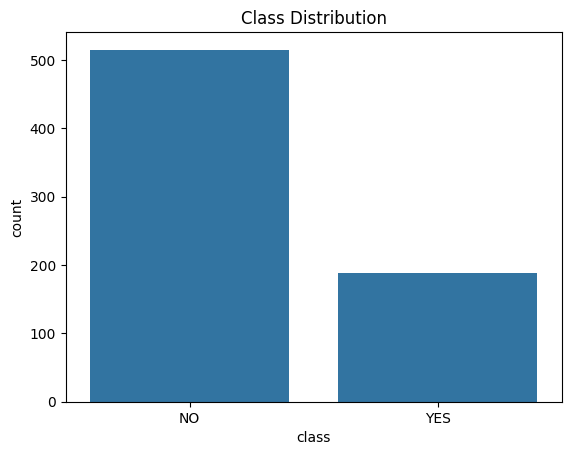

In [ ]:
sns.countplot(x='class', data=df)
plt.title("Class Distribution")
plt.show()


## **Correlation Matrix (Numerical Features)**

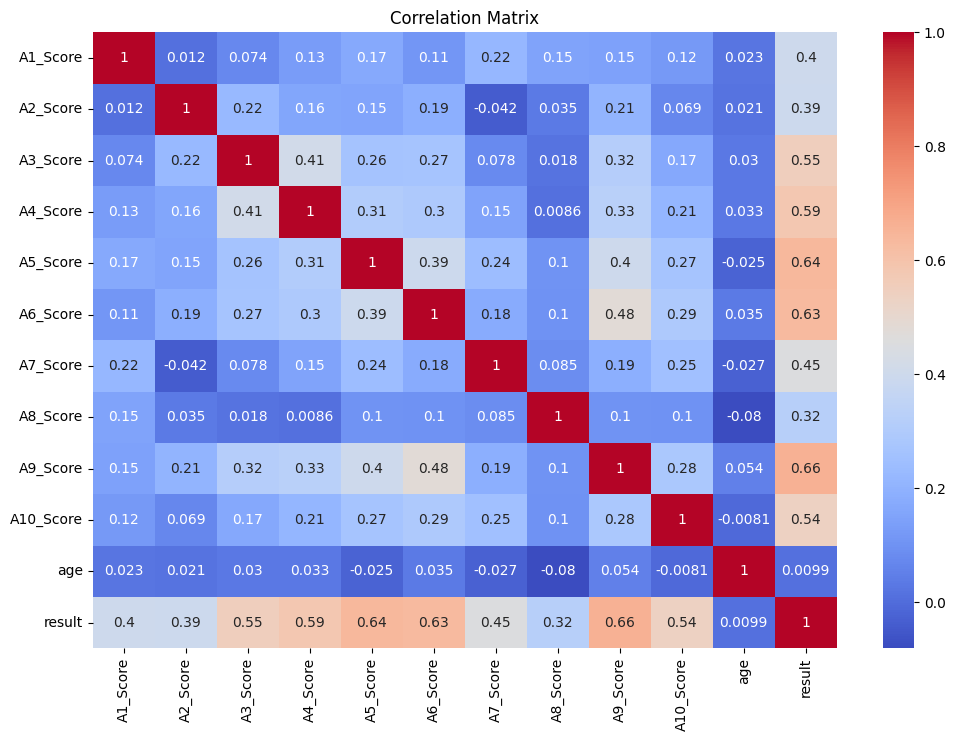

In [ ]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(12,8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


## **Outlier Detection**

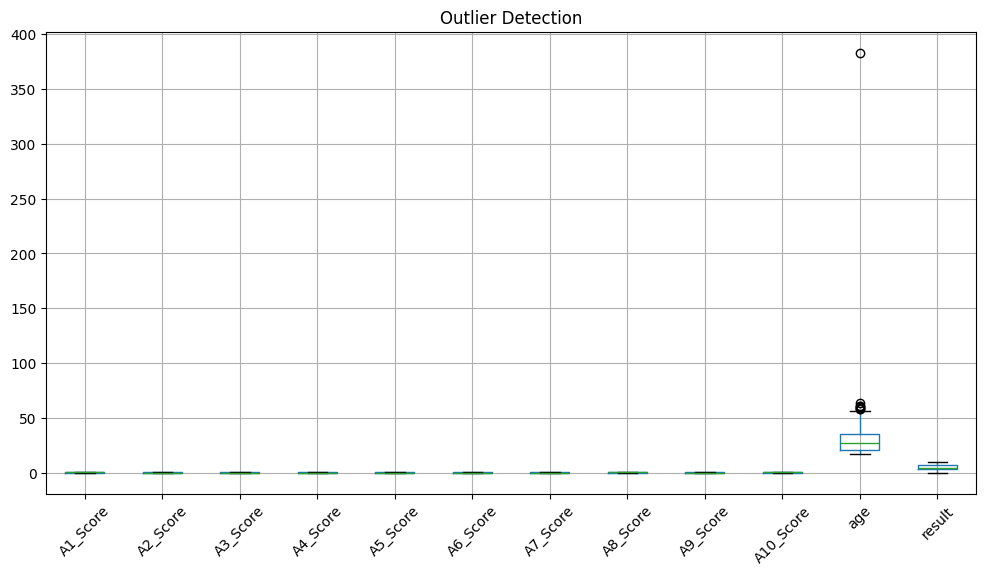

In [ ]:
plt.figure(figsize=(12,6))
df[numerical_cols].boxplot(rot=45)
plt.title("Outlier Detection")
plt.show()


## **Age Distribution**

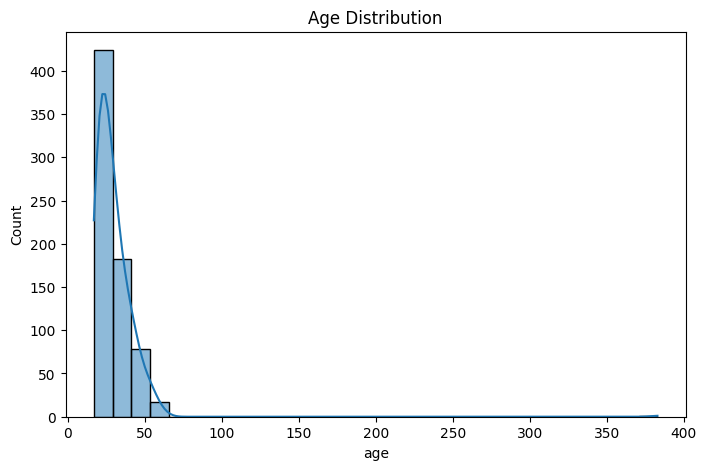

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()


In [ ]:
df.shape

(704, 21)

# **Data Preprocessing**

## **Handling Missing Values**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer

# 1. Standardize missing value markers
# The Autism dataset often uses '?' for missing data.
# We convert these to NaN so pandas and sklearn can "see" them.
df = df.replace('?', np.nan)

# 2. Check the "Missingness" status
print("--- Missing Values Per Column ---")
print(df.isnull().sum())

# 3. Identify Numerical vs Categorical columns
# This ensures we don't accidentally put a "Mean" age into the "Ethnicity" column
numeric_cols = df.select_dtypes(include=[np.number]).columns
categorical_cols = df.select_dtypes(include=['object']).columns

# 4. Define Imputation Strategies
# Strategy: Median for numbers (robust to outliers), Most Frequent for categories
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

# 5. Apply Imputation
df[numeric_cols] = num_imputer.fit_transform(df[numeric_cols])
df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])

print("\n--- Cleanup Complete ---")
print(f"Total missing values remaining: {df.isnull().sum().sum()}")

--- Missing Values Per Column ---
A1_Score            0
A2_Score            0
A3_Score            0
A4_Score            0
A5_Score            0
A6_Score            0
A7_Score            0
A8_Score            0
A9_Score            0
A10_Score           0
age                 2
gender              0
ethnicity          95
jaundice            0
family_pdd          0
country_of_res      0
used_app_before     0
result              0
age_desc            0
relation           95
class               0
dtype: int64

--- Cleanup Complete ---
Total missing values remaining: 0


## **Encoding data and Getting Ready for Training**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1. Drop 'result' to prevent data leakage and 'Class/ASD' (assuming it's your target)
# Adjust 'Class/ASD' if your target column has a different name
X = df.drop(columns=['result', 'class'])
y = df['class']

# 2. Handle Categorical Values
# We'll use LabelEncoder for simplicity, but for columns with many
# categories like 'country_of_res', OneHotEncoding is often better.
le = LabelEncoder()

# Identifying categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns

for col in categorical_cols:
    # Fill NaN with a placeholder or the mode before encoding
    X[col] = X[col].fillna(X[col].mode()[0])
    X[col] = le.fit_transform(X[col])

# 3. Divide the dataset (Train/Test Split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Scale the data
# Important: Fit on TRAIN only, then transform both to prevent leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Preprocessed features shape: {X_train_scaled.shape}")

Preprocessed features shape: (563, 19)


In [ ]:
# Print the first 5 rows of the scaled feature sets
print("=== X_train_scaled (Shape: {}) ===".format(X_train_scaled.shape))
print(X_train_scaled[:5])

print("\n=== X_test_scaled (Shape: {}) ===".format(X_test_scaled.shape))
print(X_test_scaled[:5])

# Print the first 5 rows of the target labels
print("\n=== y_train (First 5 entries) ===")
print(y_train.head())

print("\n=== y_test (First 5 entries) ===")
print(y_test.head())

=== X_train_scaled (Shape: (563, 19)) ===
[[-1.60102815 -0.94637355 -0.90664573  0.99468552 -0.97370267 -0.63284873
   1.17282881  0.75962544  1.44100754  0.86827074 -0.16375792  0.95653854
  -1.52799035 -0.3485885  -0.39804047 -0.49374572 -0.13447372  0.
   0.34881654]
 [-1.60102815  1.0566652   1.10296665  0.99468552  1.02700756  1.58015645
  -0.85263935  0.75962544  1.44100754  0.86827074 -0.67125725  0.95653854
  -1.52799035  2.86871194 -0.39804047 -1.03026932 -0.13447372  0.
   0.34881654]
 [ 0.62459864 -0.94637355 -0.90664573 -1.00534287 -0.97370267 -0.63284873
  -0.85263935  0.75962544  1.44100754 -1.1517145  -0.38931318  0.95653854
  -0.98266003 -0.3485885  -0.39804047  1.05621135 -0.13447372  0.
   0.34881654]
 [-1.60102815  1.0566652   1.10296665 -1.00534287 -0.97370267  1.58015645
  -0.85263935 -1.31643827  1.44100754  0.86827074 -0.33292437  0.95653854
  -0.98266003 -0.3485885  -0.39804047 -1.03026932 -0.13447372  0.
   0.34881654]
 [ 0.62459864  1.0566652   1.10296665  0.9

In [ ]:
# Initialize the encoder for the target
target_le = LabelEncoder()

# Fit and transform the training target, then transform the test target
y_train_encoded = target_le.fit_transform(y_train)
y_test_encoded = target_le.transform(y_test)

# To verify the mapping (usually 0 for NO, 1 for YES)
mapping = dict(zip(target_le.classes_, target_le.transform(target_le.classes_)))
print(f"Target Mapping: {mapping}")

print("\n=== y_train_encoded (First 5) ===")
print(y_train_encoded[:5])

print("\n=== y_test_encoded (First 5) ===")
print(y_test_encoded[:5])

Target Mapping: {'NO': np.int64(0), 'YES': np.int64(1)}

=== y_train_encoded (First 5) ===
[0 1 0 0 1]

=== y_test_encoded (First 5) ===
[0 0 1 0 0]


# **Model training**
## **Training & Evaluating Gradient Boosting**

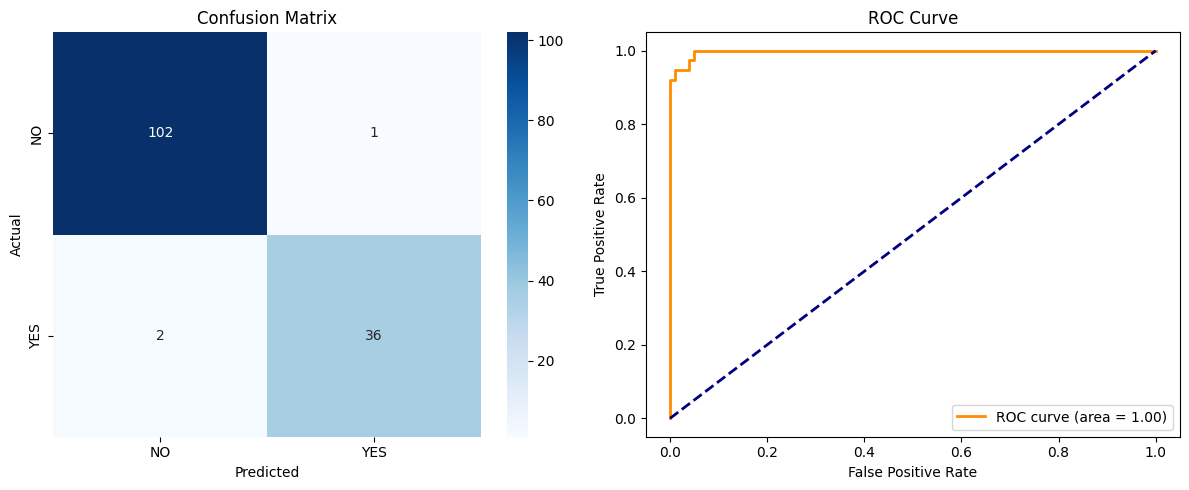


=== Final Results Table ===
               Model  Accuracy  Precision    Recall  F1-Score       AUC
0  Gradient Boosting  0.978723   0.978668  0.978723  0.978633  0.997445


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    accuracy_score
)

# Initialize results_list if it's the first model you're running
if 'results_list' not in locals():
    results_list = []

# 1. Initialize and train the model
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gb_model.fit(X_train_scaled, y_train_encoded)

# 2. Make predictions
y_pred = gb_model.predict(X_test_scaled)
y_prob = gb_model.predict_proba(X_test_scaled)[:, 1]

# 3. Generate Evaluation Metrics
# Using output_dict=True lets us extract metrics easily
report_dict = classification_report(y_test_encoded, y_pred, output_dict=True)
accuracy = accuracy_score(y_test_encoded, y_pred)

# 4. ROC Curve & AUC Calculation
fpr, tpr, thresholds = roc_curve(y_test_encoded, y_prob)
roc_auc = auc(fpr, tpr)

# --- Visualization ---

# Confusion Matrix Heatmap
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test_encoded, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['NO', 'YES'], yticklabels=['NO', 'YES'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

# ROC Curve Plot
plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

# --- Store Results ---

results_list.append({
    'Model': 'Gradient Boosting',
    'Accuracy': accuracy,
    'Precision': report_dict['weighted avg']['precision'],
    'Recall': report_dict['weighted avg']['recall'],
    'F1-Score': report_dict['weighted avg']['f1-score'],
    'AUC': roc_auc
})

# Display the final results table
results_df = pd.DataFrame(results_list)
print("\n=== Final Results Table ===")
print(results_df)

## **Training and Evaluating Naive Bayes**

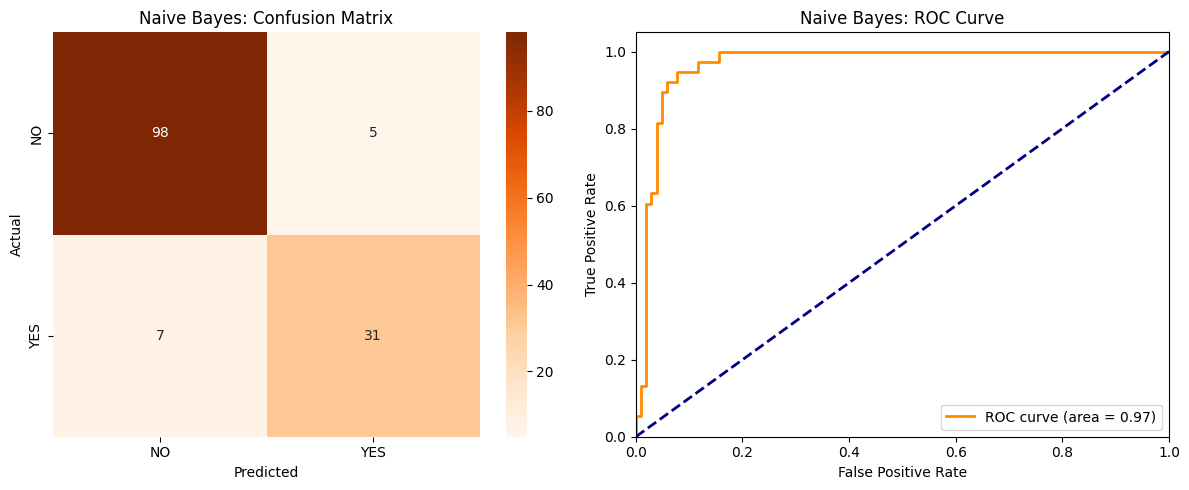


=== Updated Model Comparison Summary ===
            Model  Accuracy  Precision   Recall  F1-Score      AUC
Gradient Boosting  0.978723   0.978668 0.978723  0.978633 0.997445
      Naive Bayes  0.914894   0.861111 0.815789  0.837838 0.967552


In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_curve, auc, confusion_matrix
)

# --- 3. NAIVE BAYES ---
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train_encoded)

y_pred_nb = nb_model.predict(X_test_scaled)
y_prob_nb = nb_model.predict_proba(X_test_scaled)[:, 1]

# Store NB Metrics
fpr_nb, tpr_nb, _ = roc_curve(y_test_encoded, y_prob_nb)
roc_auc_nb = auc(fpr_nb, tpr_nb)

results_list.append({
    'Model': 'Naive Bayes',
    'Accuracy': accuracy_score(y_test_encoded, y_pred_nb),
    'Precision': precision_score(y_test_encoded, y_pred_nb),
    'Recall': recall_score(y_test_encoded, y_pred_nb),
    'F1-Score': f1_score(y_test_encoded, y_pred_nb),
    'AUC': roc_auc_nb
})

# --- VISUALIZATION (Confusion Matrix and ROC Curve) ---
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Confusion Matrix Heatmap
sns.heatmap(confusion_matrix(y_test_encoded, y_pred_nb), annot=True, fmt='d', cmap='Oranges',
            xticklabels=['NO', 'YES'], yticklabels=['NO', 'YES'], ax=ax[0])
ax[0].set_title('Naive Bayes: Confusion Matrix')
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('Actual')

# ROC Curve
ax[1].plot(fpr_nb, tpr_nb, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_nb:.2f})')
ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax[1].set_xlim([0.0, 1.0])
ax[1].set_ylim([0.0, 1.05])
ax[1].set_xlabel('False Positive Rate')
ax[1].set_ylabel('True Positive Rate')
ax[1].set_title('Naive Bayes: ROC Curve')
ax[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

# --- SUMMARY TABLE ---
summary_df = pd.DataFrame(results_list).drop_duplicates(subset=['Model'], keep='last')
print("\n=== Updated Model Comparison Summary ===")
print(summary_df.sort_values(by='AUC', ascending=False).to_string(index=False))

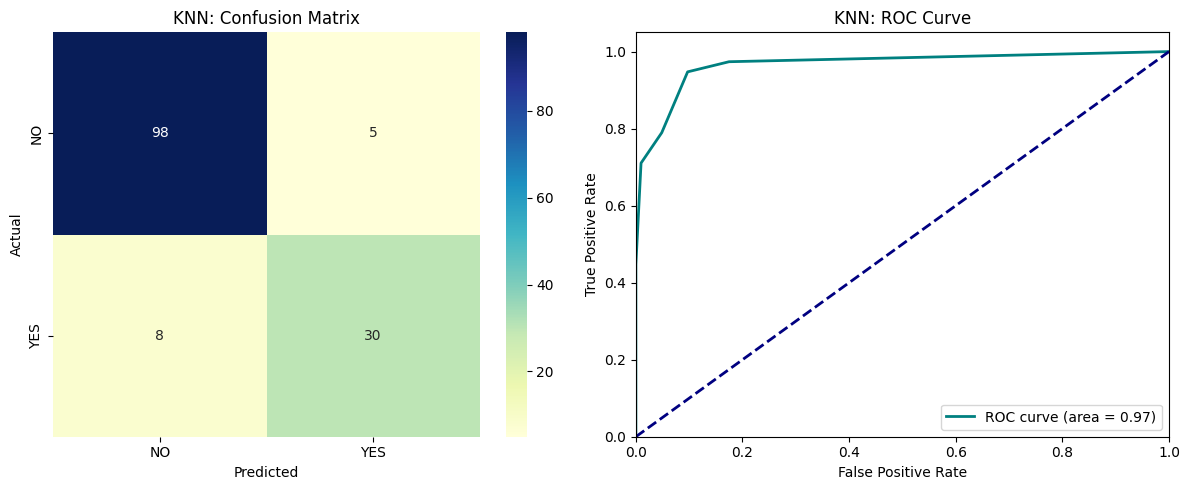


=== Updated Model Comparison Summary ===
            Model  Accuracy  Precision   Recall  F1-Score      AUC
Gradient Boosting  0.978723   0.978668 0.978723  0.978633 0.997445
      Naive Bayes  0.914894   0.861111 0.815789  0.837838 0.967552
              KNN  0.907801   0.857143 0.789474  0.821918 0.965892


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_curve, auc, confusion_matrix
)

# --- 4. K-NEAREST NEIGHBORS (KNN) ---
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train_encoded)

y_pred_knn = knn_model.predict(X_test_scaled)
y_prob_knn = knn_model.predict_proba(X_test_scaled)[:, 1]

# Store KNN Metrics
fpr_knn, tpr_knn, _ = roc_curve(y_test_encoded, y_prob_knn)
roc_auc_knn = auc(fpr_knn, tpr_knn)

results_list.append({
    'Model': 'KNN',
    'Accuracy': accuracy_score(y_test_encoded, y_pred_knn),
    'Precision': precision_score(y_test_encoded, y_pred_knn),
    'Recall': recall_score(y_test_encoded, y_pred_knn),
    'F1-Score': f1_score(y_test_encoded, y_pred_knn),
    'AUC': roc_auc_knn
})

# --- VISUALIZATION (Confusion Matrix and ROC Curve) ---
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Confusion Matrix Heatmap
sns.heatmap(confusion_matrix(y_test_encoded, y_pred_knn), annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=['NO', 'YES'], yticklabels=['NO', 'YES'], ax=ax[0])
ax[0].set_title('KNN: Confusion Matrix')
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('Actual')

# ROC Curve
ax[1].plot(fpr_knn, tpr_knn, color='teal', lw=2, label=f'ROC curve (area = {roc_auc_knn:.2f})')
ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax[1].set_xlim([0.0, 1.0])
ax[1].set_ylim([0.0, 1.05])
ax[1].set_xlabel('False Positive Rate')
ax[1].set_ylabel('True Positive Rate')
ax[1].set_title('KNN: ROC Curve')
ax[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

# --- SUMMARY TABLE ---
summary_df = pd.DataFrame(results_list).drop_duplicates(subset=['Model'], keep='last')
print("\n=== Updated Model Comparison Summary ===")
print(summary_df.sort_values(by='AUC', ascending=False).to_string(index=False))

## **Hyperparameter Optimization with Grid Search**


--- Running Gradient Boosting (Tuned) ---


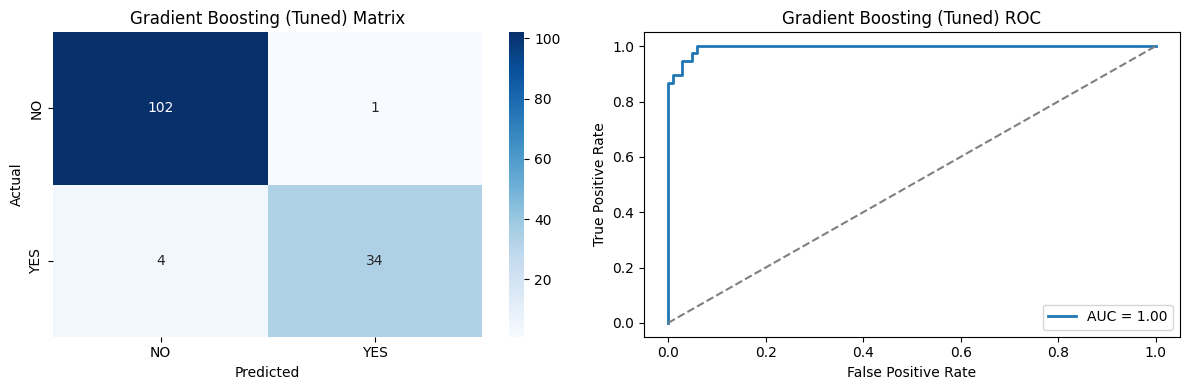


--- Running Naive Bayes ---


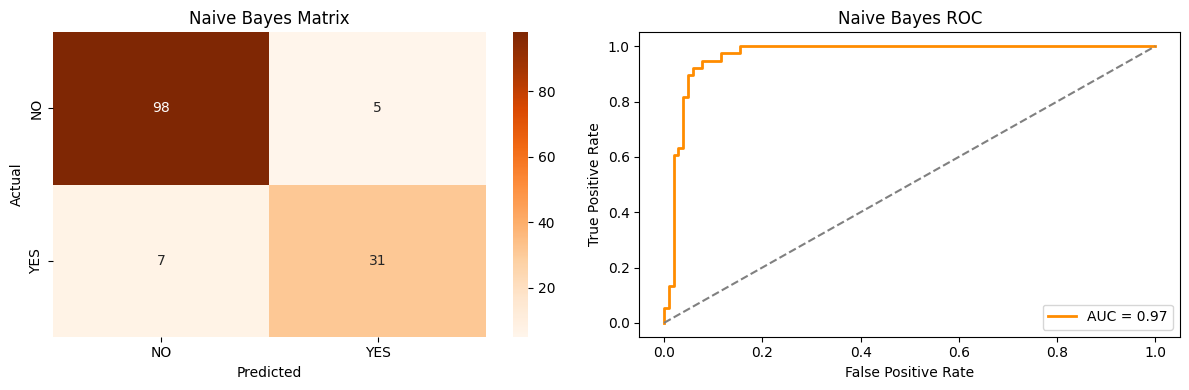


--- Running KNN (Tuned) ---


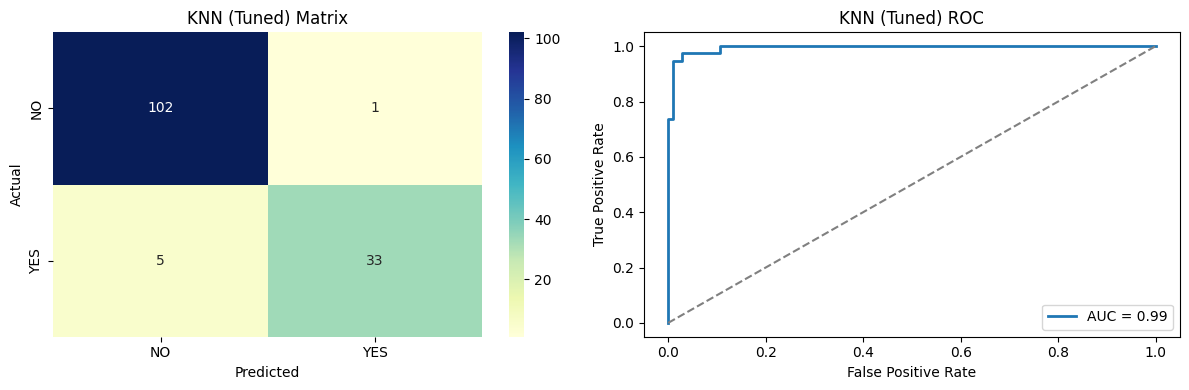


=== Current Run: Model Comparison Table ===
                    Model  Accuracy  Precision   Recall  F1-Score      AUC
Gradient Boosting (Tuned)  0.964539   0.971429 0.894737  0.931507 0.995401
              KNN (Tuned)  0.957447   0.970588 0.868421  0.916667 0.994379
              Naive Bayes  0.914894   0.861111 0.815789  0.837838 0.967552


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix, roc_curve, auc,
    accuracy_score, precision_score, recall_score, f1_score
)

# 1. Initialize a separate list for these specific models
tuned_results = []

# 2. Define model configurations
model_configs = [
    {
        'name': 'Gradient Boosting (Tuned)',
        'model': GradientBoostingClassifier(random_state=42),
        'params': {
            'n_estimators': [100, 200],
            'learning_rate': [0.01, 0.1],
            'max_depth': [3, 5]
        },
        'color': 'Blues'
    },
    {
        'name': 'Naive Bayes',
        'model': GaussianNB(),
        'params': {},  # GaussianNB doesn't usually require tuning
        'color': 'Oranges'
    },
    {
        'name': 'KNN (Tuned)',
        'model': KNeighborsClassifier(),
        'params': {
            'n_neighbors': [3, 5, 11],
            'weights': ['uniform', 'distance'],
            'metric': ['euclidean', 'manhattan']
        },
        'color': 'YlGnBu'
    }
]

# 3. Iterate through each model configuration
for config in model_configs:
    print(f"\n--- Running {config['name']} ---")

    # Run Grid Search (CV=5)
    grid = GridSearchCV(
        estimator=config['model'],
        param_grid=config['params'],
        cv=5,
        scoring='f1',
        n_jobs=-1
    )
    grid.fit(X_train_scaled, y_train_encoded)

    # Extract best model and predictions
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test_scaled)
    y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

    # Calculate ROC metrics
    fpr, tpr, _ = roc_curve(y_test_encoded, y_prob)
    roc_auc = auc(fpr, tpr)

    # Store Metrics in the new list
    metrics = {
        'Model': config['name'],
        'Accuracy': accuracy_score(y_test_encoded, y_pred),
        'Precision': precision_score(y_test_encoded, y_pred),
        'Recall': recall_score(y_test_encoded, y_pred),
        'F1-Score': f1_score(y_test_encoded, y_pred),
        'AUC': roc_auc
    }
    tuned_results.append(metrics)

    # 4. Visualizations
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    # Confusion Matrix Heatmap
    sns.heatmap(confusion_matrix(y_test_encoded, y_pred), annot=True, fmt='d',
                cmap=config['color'], xticklabels=['NO', 'YES'], yticklabels=['NO', 'YES'], ax=ax[0])
    ax[0].set_title(f"{config['name']} Matrix")
    ax[0].set_xlabel('Predicted')
    ax[0].set_ylabel('Actual')

    # ROC Curve
    ax[1].plot(fpr, tpr, color='darkorange' if config['color']=='Oranges' else None,
               lw=2, label=f'AUC = {roc_auc:.2f}')
    ax[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
    ax[1].set_title(f"{config['name']} ROC")
    ax[1].set_xlabel('False Positive Rate')
    ax[1].set_ylabel('True Positive Rate')
    ax[1].legend(loc='lower right')

    plt.tight_layout()
    plt.show()

# 5. Final Summary Table for this run
tuned_summary_df = pd.DataFrame(tuned_results)
print("\n=== Current Run: Model Comparison Table ===")
print(tuned_summary_df.sort_values(by='F1-Score', ascending=False).to_string(index=False))

## **K-Fold Cross Validation**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import cross_validate
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# 1. Define the models for Cross-Validation
# You can use the "best" parameters from your previous GridSearch here
models_to_cv = {
    'Gradient Boosting': GradientBoostingClassifier(random_state=42, n_estimators=100, learning_rate=0.1, max_depth=3),
    'Naive Bayes': GaussianNB(),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

# 2. Define the metrics we want to track
scoring_metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

cv_results_list = []

print("--- Starting 5-Fold Cross-Validation (GB, NB, KNN) ---")

for name, model in models_to_cv.items():
    # Perform Cross-Validation on the training set
    cv_scores = cross_validate(
        model,
        X_train_scaled,
        y_train_encoded,
        cv=5,
        scoring=scoring_metrics,
        n_jobs=-1 # Uses all processors for speed
    )

    # Calculate Mean and Standard Deviation for each metric
    res = {'Model': name}
    for metric in scoring_metrics:
        mean_val = np.mean(cv_scores[f'test_{metric}'])
        std_val = np.std(cv_scores[f'test_{metric}'])

        # Rounding for a cleaner table
        res[f'{metric.capitalize()} (Mean)'] = round(mean_val, 4)
        res[f'{metric.capitalize()} (Std)'] = round(std_val, 4)

    cv_results_list.append(res)
    print(f"✔ Completed CV for {name}")

# 3. Create DataFrame and Display
cv_df = pd.DataFrame(cv_results_list)

# Reorganizing columns for readability (Mean next to Std)
final_cols = ['Model']
for m in ['Accuracy', 'Precision', 'Recall', 'F1', 'Roc_auc']:
    final_cols.extend([f'{m} (Mean)', f'{m} (Std)'])

print("\n=== Final K-Fold Cross-Validation Summary ===")
print(cv_df[final_cols].sort_values(by='F1 (Mean)', ascending=False).to_string(index=False))

--- Starting 5-Fold Cross-Validation (GB, NB, KNN) ---
✔ Completed CV for Gradient Boosting
✔ Completed CV for Naive Bayes
✔ Completed CV for KNN

=== Final K-Fold Cross-Validation Summary ===
            Model  Accuracy (Mean)  Accuracy (Std)  Precision (Mean)  Precision (Std)  Recall (Mean)  Recall (Std)  F1 (Mean)  F1 (Std)  Roc_auc (Mean)  Roc_auc (Std)
              KNN           0.9503          0.0181            0.8722           0.0558         0.9604        0.0323     0.9127    0.0299          0.9833         0.0107
Gradient Boosting           0.9467          0.0169            0.9263           0.0447         0.8740        0.0714     0.8968    0.0347          0.9939         0.0061
      Naive Bayes           0.9432          0.0133            0.9023           0.0392         0.8875        0.0539     0.8931    0.0262          0.9803         0.0122


# **Handling Class Imbalance**


--- Testing Resampling Method: SMOTE ---


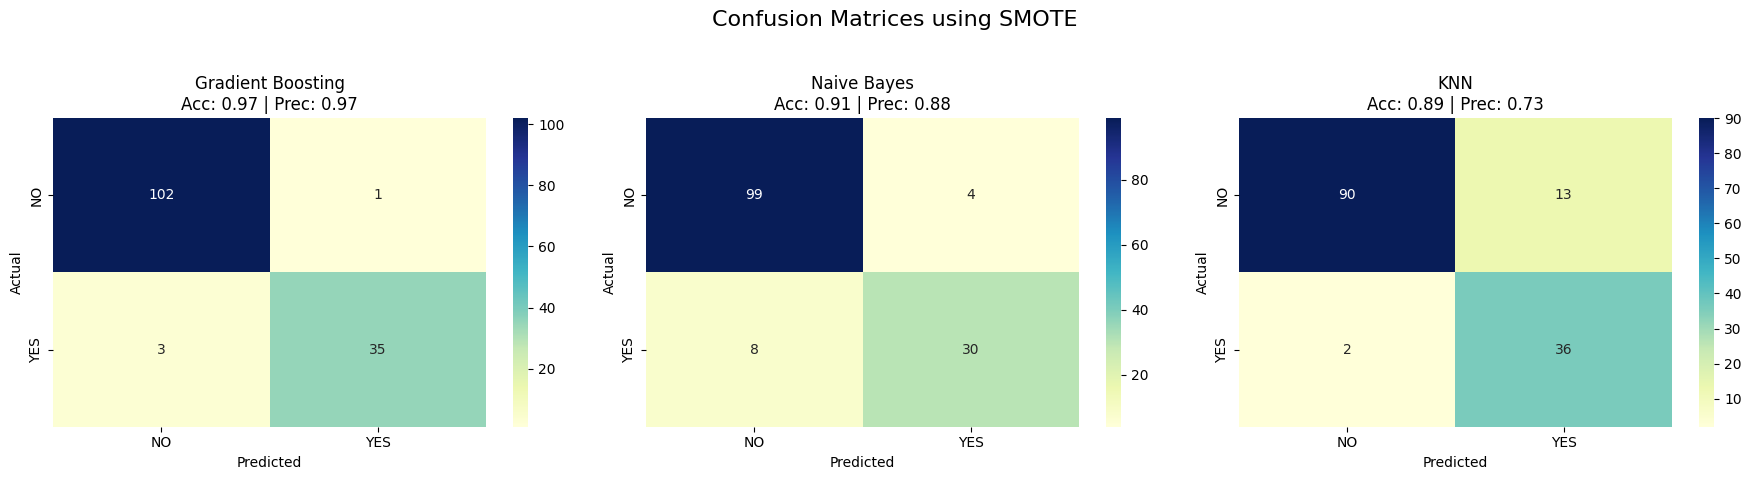


--- Testing Resampling Method: RandomOverSampler ---


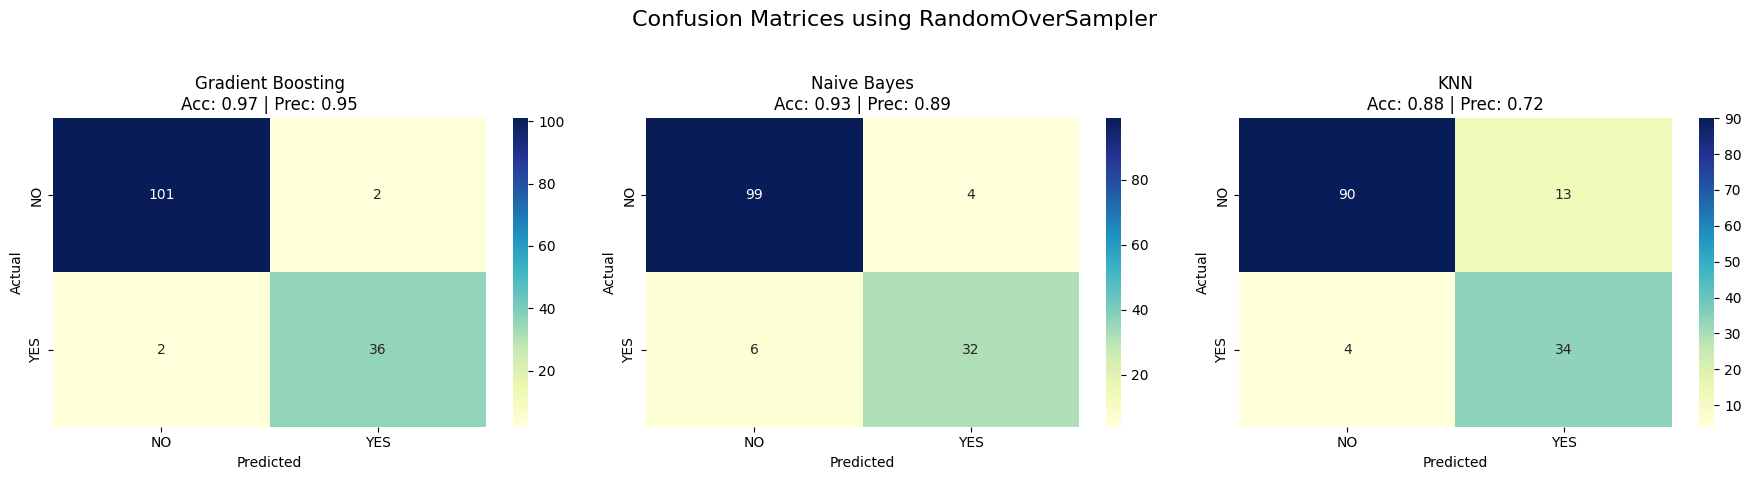


--- Testing Resampling Method: RandomUnderSampler ---


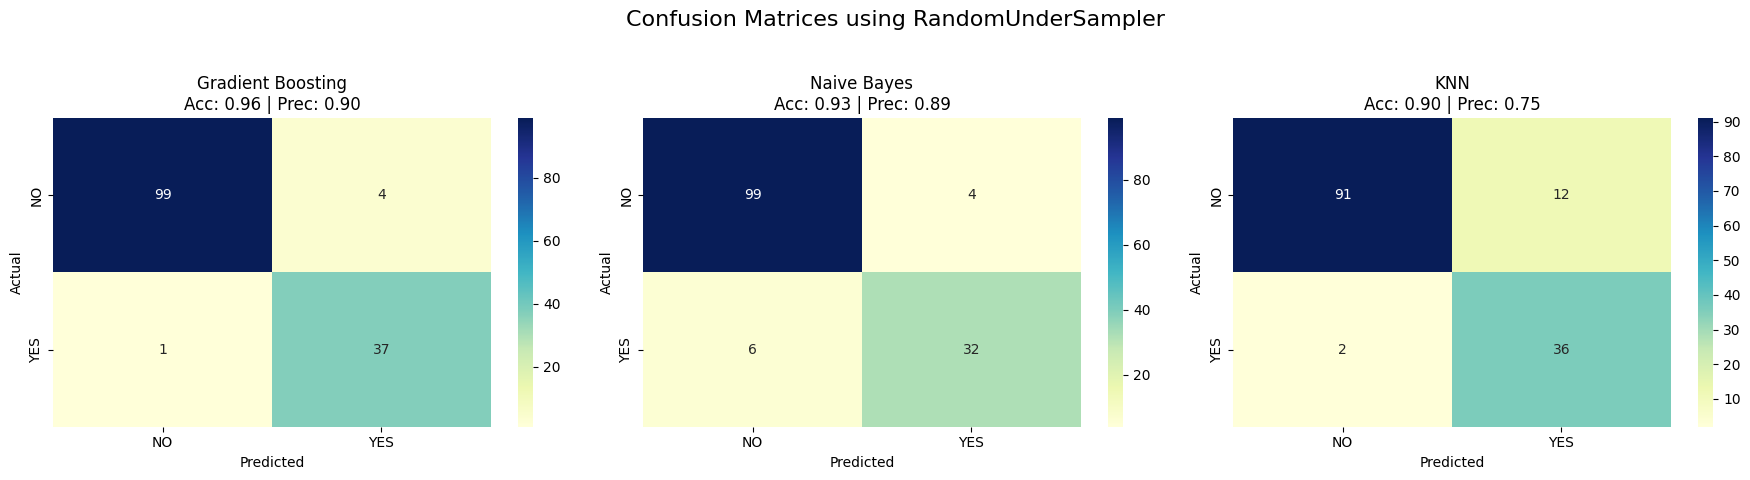


=== Comprehensive Resampling Comparison Table ===
                                      Accuracy  Precision    Recall  F1-Score  \
Sampler            Model                                                        
RandomOverSampler  Gradient Boosting  0.971631   0.947368  0.947368  0.947368   
                   Naive Bayes        0.929078   0.888889  0.842105  0.864865   
                   KNN                0.879433   0.723404  0.894737  0.800000   
RandomUnderSampler Gradient Boosting  0.964539   0.902439  0.973684  0.936709   
                   Naive Bayes        0.929078   0.888889  0.842105  0.864865   
                   KNN                0.900709   0.750000  0.947368  0.837209   
SMOTE              Gradient Boosting  0.971631   0.972222  0.921053  0.945946   
                   Naive Bayes        0.914894   0.882353  0.789474  0.833333   
                   KNN                0.893617   0.734694  0.947368  0.827586   

                                           AUC  
Sampler 

In [ ]:
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, roc_curve, auc,
    accuracy_score, precision_score, recall_score, f1_score
)

# 1. Define the models
models = {
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Naive Bayes': GaussianNB(),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

# 2. Define the resampling methods
samplers = {
    'SMOTE': SMOTE(random_state=42),
    'RandomOverSampler': RandomOverSampler(random_state=42),
    'RandomUnderSampler': RandomUnderSampler(random_state=42)
}

imbalance_results = []

# 3. Execution Loop
for sampler_name, sampler in samplers.items():
    print(f"\n--- Testing Resampling Method: {sampler_name} ---")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Confusion Matrices using {sampler_name}', fontsize=16)

    for idx, (model_name, model) in enumerate(models.items()):
        # Pipeline ensures resampling only happens on training data to avoid leakage
        pipeline = Pipeline([
            ('sampler', sampler),
            ('classifier', model)
        ])

        pipeline.fit(X_train_scaled, y_train_encoded)
        y_pred = pipeline.predict(X_test_scaled)
        y_prob = pipeline.predict_proba(X_test_scaled)[:, 1]

        # Calculate All Metrics
        acc = accuracy_score(y_test_encoded, y_pred)
        prec = precision_score(y_test_encoded, y_pred)
        rec = recall_score(y_test_encoded, y_pred)
        f1 = f1_score(y_test_encoded, y_pred)
        auc_score = auc(*roc_curve(y_test_encoded, y_prob)[:2])

        imbalance_results.append({
            'Sampler': sampler_name,
            'Model': model_name,
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1-Score': f1,
            'AUC': auc_score
        })

        # Visualization: Confusion Matrix
        cm = confusion_matrix(y_test_encoded, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', ax=axes[idx],
                    xticklabels=['NO', 'YES'], yticklabels=['NO', 'YES'])
        axes[idx].set_title(f"{model_name}\nAcc: {acc:.2f} | Prec: {prec:.2f}")
        axes[idx].set_xlabel('Predicted')
        axes[idx].set_ylabel('Actual')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# 4. Final Comparison Summary
imbalance_df = pd.DataFrame(imbalance_results)

# Create a clean multi-index table to compare Sampler vs Model across all metrics
summary_pivot = imbalance_df.set_index(['Sampler', 'Model'])

print("\n=== Comprehensive Resampling Comparison Table ===")
print(summary_pivot.sort_values(by=['Sampler', 'F1-Score'], ascending=[True, False]))

# **Model Interpretability using XXAI**

## **sHAP based Interpretability**

--- SHAP Summary Plot (Gradient Boosting) ---


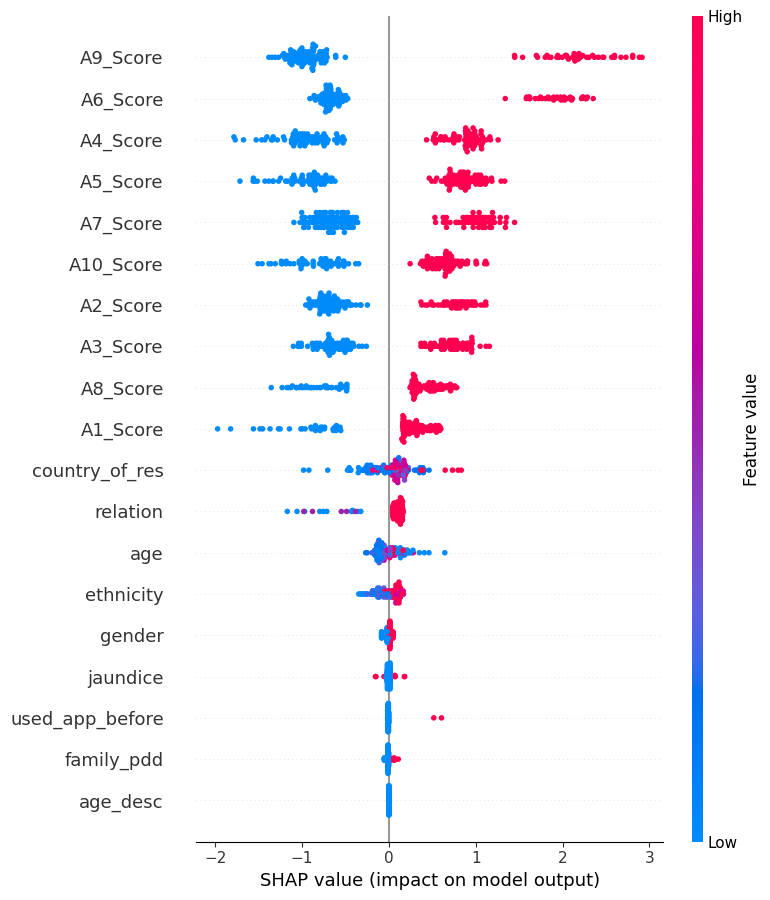

--- SHAP Feature Importance (Bar Plot) ---


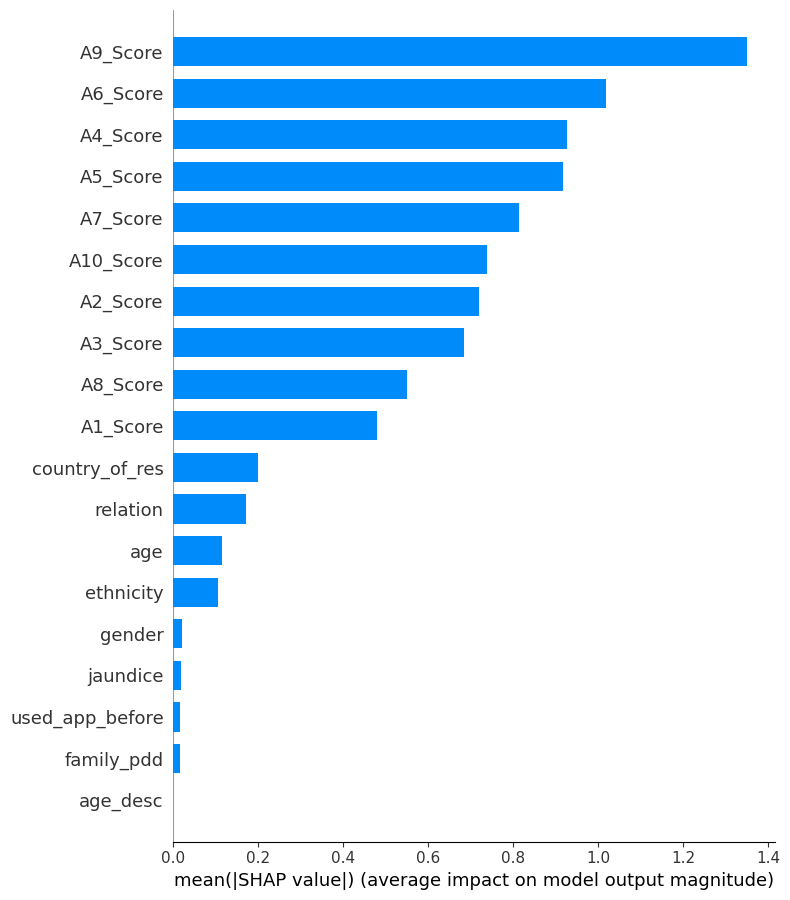

--- SHAP Force Plot for 1st instance ---


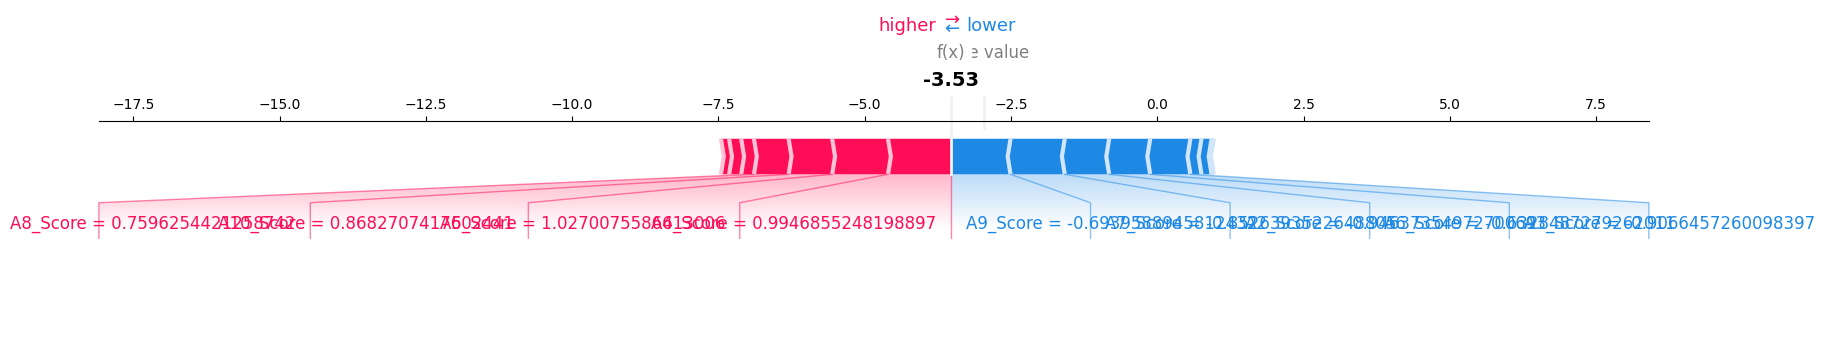

In [ ]:
import shap
import matplotlib.pyplot as plt

# 1. Initialize the SHAP Explainer
# best_model should be the Gradient Boosting instance
# Correcting the error by using the previously trained Gradient Boosting model (gb_model)
explainer = shap.TreeExplainer(gb_model)

# 2. Calculate SHAP values
# X_test_scaled is used to explain the model's behavior on the test set
shap_values = explainer.shap_values(X_test_scaled)

# For Sklearn's GradientBoostingClassifier, shap_values is typically a 2D array [samples, features]
# representing the contribution toward the positive class.
# We'll use a copy to be safe for plotting.
shap_values_for_plot = shap_values

# 3. Visualizations

# A. Summary Plot: Combines feature importance with the direction of impact
# This tells you if a high feature value increases or decreases the prediction.
print("--- SHAP Summary Plot (Gradient Boosting) ---")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_for_plot, X_test_scaled, feature_names=X.columns)

# B. Bar Plot: Global feature importance (Mean Absolute SHAP)
print("--- SHAP Feature Importance (Bar Plot) ---")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_for_plot, X_test_scaled, feature_names=X.columns, plot_type="bar")

# C. Force Plot for a single prediction (1st instance)
# This breaks down how specific feature values "pushed" the model toward the final result.
shap.initjs()
print("--- SHAP Force Plot for 1st instance ---")

# For Gradient Boosting, expected_value is usually a single scalar (the base logit)
# whereas for RF it might be a list. We handle both:
base_value = explainer.expected_value[0] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value

shap.force_plot(
    base_value,
    shap_values_for_plot[0, :],
    X_test_scaled[0, :],
    feature_names=X.columns,
    matplotlib=True
)

## **Lime Based Interpretability**

In [ ]:
!pip install LIME

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for LIME: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=bcdad4eaa61db60a04ae8d13205cd52be4424a1599f752dc89ea3eac788f9a03
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built LIME


In [ ]:
import numpy as np
from lime import lime_tabular
import matplotlib.pyplot as plt

# 1. Initialize the LIME Explainer
# training_data: Needs to be a numpy array
# mode: 'classification' for our YES/NO target
explainer_lime = lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train_scaled),
    feature_names=X.columns.tolist(),
    class_names=['NO', 'YES'],
    mode='classification'
)

# 2. Pick a specific instance to explain
# Index 0 is the first row of your test set
i = 0
instance = X_test_scaled[i]

# 3. Generate Explanation
# predict_fn: We pass the predict_proba method of our best Gradient Boosting model
exp = explainer_lime.explain_instance(
    data_row=instance,
    predict_fn=best_model.predict_proba,
    num_features=10
)

# 4. Visualize the Explanation
print(f"--- LIME Explanation for Instance {i} (Gradient Boosting) ---")
print(f"Actual Label: {y_test_encoded[i]}")

# Reshaping instance for a single prediction
prediction = best_model.predict(instance.reshape(1, -1))[0]
probability = best_model.predict_proba(instance.reshape(1, -1))[0]
print(f"Predicted Label: {prediction} (Probabilities: {probability})")

# Visualization
# This works best in Jupyter/Colab environments
try:
    exp.show_in_notebook(show_table=True)
except:
    # Fallback for standard Python scripts or environments where JS isn't supported
    exp.as_pyplot_figure()
    plt.tight_layout()
    plt.show()

--- LIME Explanation for Instance 0 (Gradient Boosting) ---
Actual Label: 0
Predicted Label: 0 (Probabilities: [0.94267144 0.05732856])
